In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split, GroupShuffleSplit

In [8]:
df = pd.read_csv('/home/jaalzate/BIMCV-Prostate-Classification/Files/training_df.csv')

In [13]:
df.partition.value_counts()

partition
train    4446
val       217
Name: count, dtype: int64

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4663 entries, 0 to 4662
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   subject          4663 non-null   object 
 1   session          4663 non-null   object 
 2   image_t2         4663 non-null   object 
 3   image_dwi        4663 non-null   object 
 4   image_adc        4663 non-null   object 
 5   dep              4663 non-null   float64
 6   ED               4663 non-null   float64
 7   AF               54 non-null     float64
 8   TB               2223 non-null   float64
 9   TR               15 non-null     float64
 10  PSA              4271 non-null   float64
 11  VP               2907 non-null   float64
 12  PIR              1657 non-null   float64
 13  csPC             4663 non-null   float64
 14  F_nacimiento     4663 non-null   object 
 15  F_RM             4663 non-null   object 
 16  partition        4663 non-null   object 
 17  Derivative    

In [10]:
#Check for columns where ED, AF, TB, TR, PSA, VP are not nan

df_not_na = df.dropna(subset=['ED', 'PSA', 'VP'])

In [11]:
df_not_na['PSA_density'] = df_not_na['PSA'] / df_not_na['VP']

/tmp/ipykernel_214759/569724825.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_not_na['PSA_density'] = df_not_na['PSA'] / df_not_na['VP']


In [12]:
df_not_na

,subject,session,image_t2,image_dwi,image_adc,dep,ED,AF,TB,TR,PSA,VP,PIR,csPC,F_nacimiento,F_RM,partition,Derivative,VP_segmentation,PSA_density
3,sub-002299,ses-004352,/sub-002299/ses-004352/mim-mr/anat/sub-002299_...,/sub-002299/ses-004352/mim-mr/dwi/sub-002299_s...,/sub-002299/ses-004352/mim-mr/dwi/sub-002299_s...,17.0,82.0,NaN,2.0,NaN,0.014,38.88404,NaN,1.0,1935-05-07,2014-12-25,train,False,NaN,0.000360
4,sub-002299,ses-004352,/sub-002299/ses-004352/mim-mr/anat/sub-002299_...,/sub-002299/ses-004352/mim-mr/dwi/sub-002299_s...,/sub-002299/ses-004352/mim-mr/dwi/sub-002299_s...,17.0,82.0,NaN,2.0,NaN,0.014,38.88404,NaN,1.0,1935-05-07,2014-12-25,train,False,NaN,0.000360
5,sub-002299,ses-004352,/sub-002299/ses-004352/mim-mr/anat/sub-002299_...,/sub-002299/ses-004352/mim-mr/dwi/sub-002299_s...,/sub-002299/ses-004352/mim-mr/dwi/sub-002299_s...,17.0,82.0,NaN,2.0,NaN,0.014,38.88404,NaN,1.0,1935-05-07,2014-12-25,train,False,NaN,0.000360
8,sub-005249,ses-005651,/sub-005249/ses-005651/mim-mr/anat/sub-005249_...,/sub-005249/ses-005651/mim-mr/dwi/sub-005249_s...,/sub-005249/ses-005651/mim-mr/dwi/sub-005249_s...,17.0,60.0,NaN,5.0,NaN,5.150,44.92800,4.0,1.0,1948-12-08,2009-05-12,train,False,NaN,0.114628
9,sub-005249,ses-005651,/sub-005249/ses-005651/mim-mr/anat/sub-005249_...,/sub-005249/ses-005651/mim-mr/dwi/sub-005249_s...,/sub-005249/ses-005651/mim-mr/dwi/sub-005249_s...,17.0,60.0,NaN,5.0,NaN,5.150,44.92800,4.0,1.0,1948-12-08,2009-05-12,train,False,NaN,0.114628
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4650,sub-000069,ses-000069,/sub-000069/ses-000069/mim-mr/anat/sub-000069_...,/sub-000069/ses-000069/mim-mr/dwi/sub-000069_s...,/derivatives/creating_adc/sub-000069/ses-00006...,7.0,65.0,NaN,1.0,NaN,13.010,134.18496,NaN,0.0,1948-05-27,2011-04-12,val,True,117.268066,0.096956
4652,sub-000092,ses-000092,/sub-000092/ses-000092/mim-mr/anat/sub-000092_...,/sub-000092/ses-000092/mim-mr/dwi/sub-000092_s...,/derivatives/creating_adc/sub-000092/ses-00009...,7.0,69.0,NaN,2.0,NaN,7.240,0.52000,NaN,0.0,1945-10-31,2014-10-02,val,True,149.049316,13.923077
4653,sub-000092,ses-000092,/sub-000092/ses-000092/mim-mr/anat/sub-000092_...,/sub-000092/ses-000092/mim-mr/dwi/sub-000092_s...,/derivatives/creating_adc/sub-000092/ses-00009...,7.0,69.0,NaN,2.0,NaN,7.240,0.52000,NaN,0.0,1945-10-31,2014-10-02,val,True,149.049316,13.923077
4656,sub-000120,ses-000120,/sub-000120/ses-000120/mim-mr/anat/sub-000120_...,/sub-000120/ses-000120/mim-mr/dwi/sub-000120_s...,/derivatives/creating_adc/sub-000120/ses-00012...,7.0,69.0,NaN,1.0,NaN,5.840,34.00000,4.0,0.0,1945-06-17,2014-09-24,val,True,37.376660,0.171765


In [28]:
df_not_na=df_not_na.reset_index(drop=True)
train_idx, test_idx = next(GroupShuffleSplit(test_size=.20, n_splits=2, random_state=42).split(df_not_na, groups=df_not_na['subject']))
df_not_na.loc[train_idx, 'partition'] = 'train'
df_not_na.loc[test_idx, 'partition'] = 'val'

In [29]:
df_not_na.partition.value_counts()

partition
train    2130
val       540
Name: count, dtype: int64

In [27]:
df_not_na[df_not_na.partition=='test'].csPC.value_counts()

csPC
1.0    301
0.0    239
Name: count, dtype: int64

In [30]:
df_not_na.to_csv('/home/jaalzate/BIMCV-Prostate-Classification/Files/training_df_variables_not_na.csv', index=False)

In [14]:
df_not_na['csPC'].value_counts()

csPC
0.0    1404
1.0    1266
Name: count, dtype: int64

# Training Test

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GroupShuffleSplit,GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix, roc_curve, auc
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [3]:
# Cargar el archivo CSV
file_path = "/home/jaalzate/BIMCV-Prostate-Classification/Files/training_df_variables_not_na.csv"
df = pd.read_csv(file_path)

# Seleccionar variables de interés
variables = ["ED", "PSA", "VP", "PSA_density", "csPC"]
df_filtered = df[variables].dropna()

# Eliminar valores extremos basados en percentiles
lower_bound = df_filtered.quantile(0.01)
upper_bound = df_filtered.quantile(0.99)
df_cleaned = df_filtered[(df_filtered >= lower_bound) & (df_filtered <= upper_bound)].dropna()

In [68]:
df_cleaned.csPC.value_counts()

csPC
0.0    1358
1.0    1167
Name: count, dtype: int64

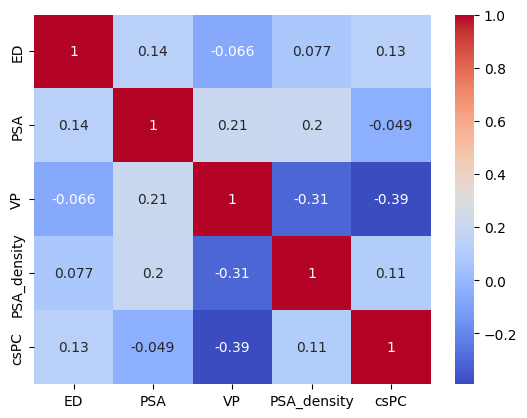

In [69]:
#Check Correlation
corr = df_cleaned[["ED", "PSA", "VP", "PSA_density","csPC"]].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [74]:
# Separar características y variable objetivo
X = df_cleaned.drop(columns=["csPC"])
y = df_cleaned["csPC"]
subjects = df.iloc[X.index]['subject'].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=subjects))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
# Normalizar las características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [71]:
# Modelos de Machine Learning
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier()
}

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

         0.0       0.74      0.67      0.70       281
         1.0       0.65      0.73      0.69       241

    accuracy                           0.69       522
   macro avg       0.69      0.70      0.69       522
weighted avg       0.70      0.69      0.69       522

Classification Report for Random Forest:
              precision    recall  f1-score   support

         0.0       0.68      0.65      0.66       281
         1.0       0.61      0.65      0.63       241

    accuracy                           0.65       522
   macro avg       0.65      0.65      0.65       522
weighted avg       0.65      0.65      0.65       522

Classification Report for Gradient Boosting:
              precision    recall  f1-score   support

         0.0       0.70      0.67      0.68       281
         1.0       0.63      0.67      0.65       241

    accuracy                           0.67      

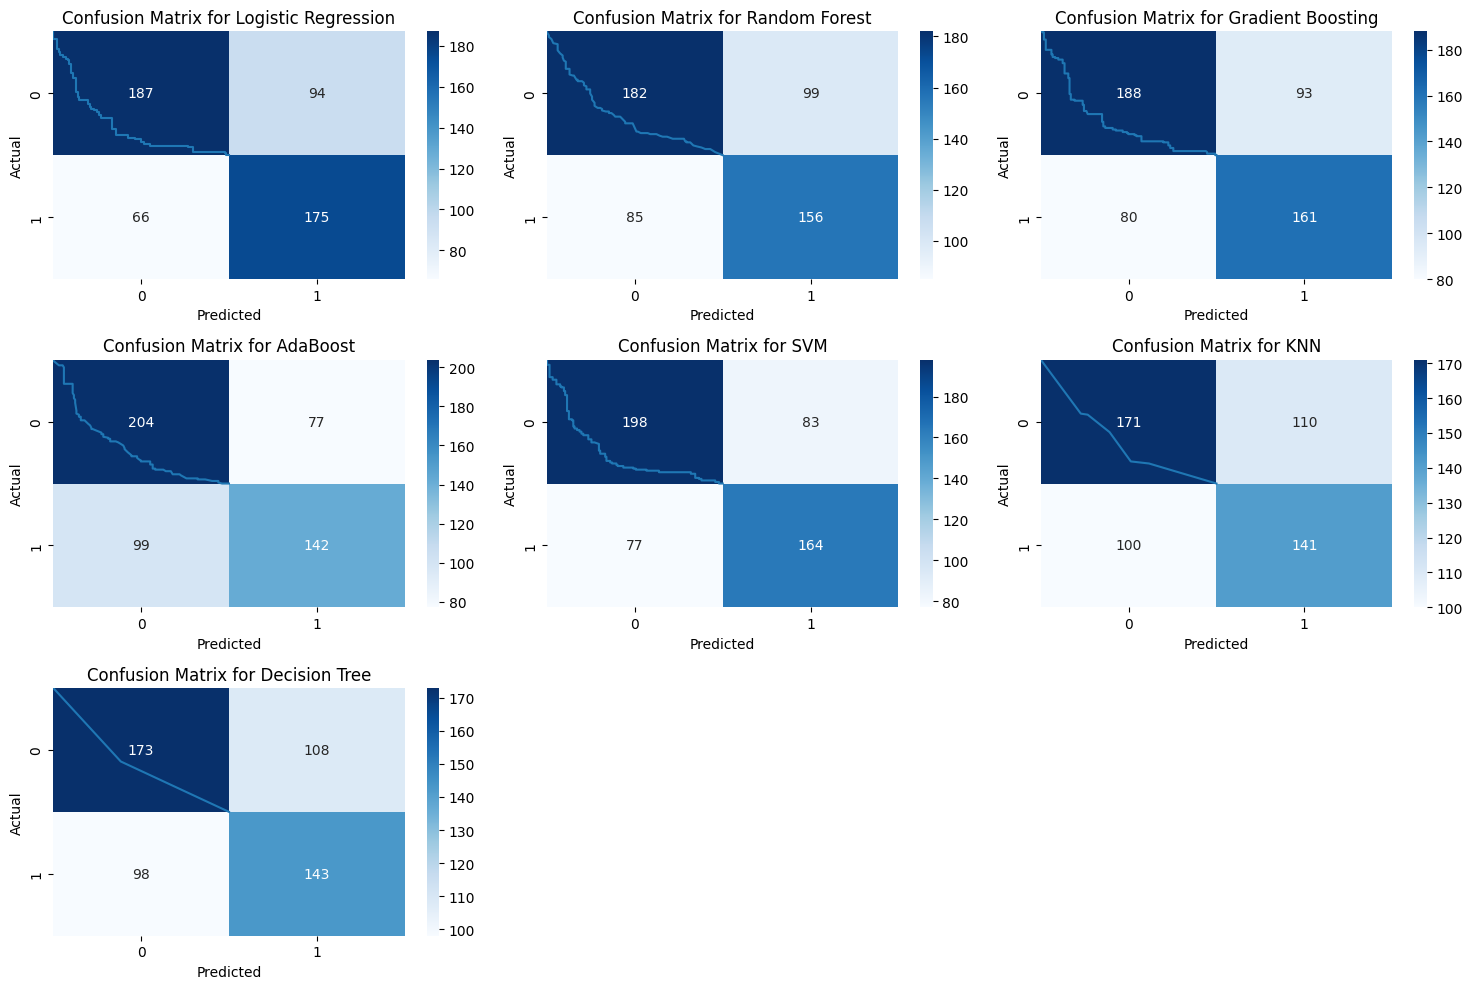

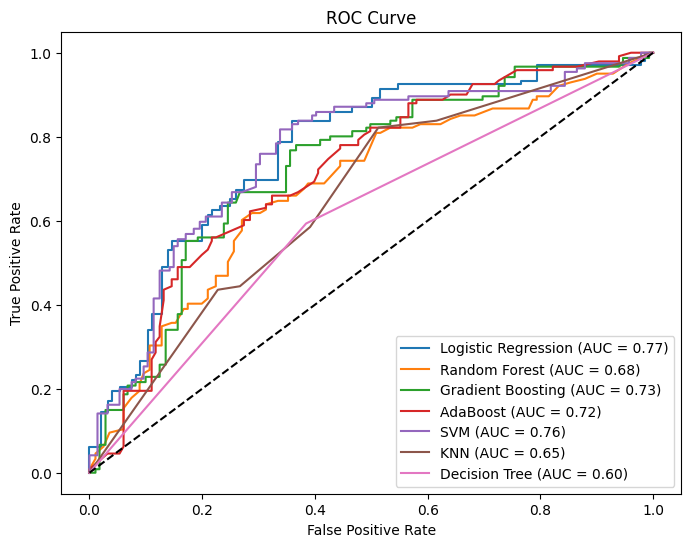

In [72]:
# Entrenar y evaluar modelos
results = []
plt.figure(figsize=(15, 10))
for i, (name, model) in enumerate(models.items()):
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, "predict_proba") else y_pred
    
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    
    print(f"Classification Report for {name}:\n{classification_report(y_test, y_pred)}")
    cm = confusion_matrix(y_test, y_pred)
    
    plt.subplot(3, 3, i + 1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix for {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')
    
    results.append({"Model": name, "Accuracy": accuracy, "F1 Score": f1, "ROC AUC": roc_auc})

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
for name, model in models.items():
    y_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, "predict_proba") else y_pred
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# Convertir resultados a DataFrame
results_df = pd.DataFrame(results)

## Cross Validation

In [75]:
X

,ED,PSA,VP,PSA_density
3,60.0,5.15,44.92800,0.114628
4,60.0,5.15,44.92800,0.114628
5,60.0,5.15,44.92800,0.114628
6,61.0,8.03,44.92800,0.178730
7,61.0,8.03,44.92800,0.178730
...,...,...,...,...
2663,62.0,5.48,50.00000,0.109600
2664,73.0,31.78,40.00000,0.794500
2665,65.0,13.01,134.18496,0.096956
2668,69.0,5.84,34.00000,0.171765


In [77]:
results = []
gkf = GroupKFold(n_splits=5)
results = []
averages = []
for name, model in models.items():
    fold_results = []
    for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=subjects)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, "predict_proba") else y_pred
        
        accuracy = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_proba)
        
        print(f"{name} - Fold {fold+1}: Accuracy = {accuracy:.4f}, F1 Score = {f1:.4f}, ROC AUC = {roc_auc:.4f}")
        
        fold_results.append({"Fold": fold+1, "Model": name, "Accuracy": accuracy, "F1 Score": f1, "ROC AUC": roc_auc})
    
    results.extend(fold_results)
    avg_results = {
        "Model": name,
        "Mean Accuracy": np.mean([r["Accuracy"] for r in fold_results]),
        "Std Accuracy": np.std([r["Accuracy"] for r in fold_results]),
        "Mean F1 Score": np.mean([r["F1 Score"] for r in fold_results]),
        "Std F1 Score": np.std([r["F1 Score"] for r in fold_results]),
        "Mean ROC AUC": np.mean([r["ROC AUC"] for r in fold_results]),
        "Std ROC AUC": np.std([r["ROC AUC"] for r in fold_results])
    }
    averages.append(avg_results)

# Convertir resultados a DataFrame
results_df = pd.DataFrame(results)
averages_df = pd.DataFrame(averages)

# Mostrar resultados
display(results_df)
display(averages_df)

Logistic Regression - Fold 1: Accuracy = 0.6772, F1 Score = 0.6810, ROC AUC = 0.7163
Logistic Regression - Fold 2: Accuracy = 0.7149, F1 Score = 0.7241, ROC AUC = 0.8110
Logistic Regression - Fold 3: Accuracy = 0.6713, F1 Score = 0.6407, ROC AUC = 0.7295
Logistic Regression - Fold 4: Accuracy = 0.6733, F1 Score = 0.6497, ROC AUC = 0.7973
Logistic Regression - Fold 5: Accuracy = 0.6970, F1 Score = 0.6695, ROC AUC = 0.7276
Random Forest - Fold 1: Accuracy = 0.6218, F1 Score = 0.5821, ROC AUC = 0.6876
Random Forest - Fold 2: Accuracy = 0.6436, F1 Score = 0.6371, ROC AUC = 0.7077
Random Forest - Fold 3: Accuracy = 0.6158, F1 Score = 0.5591, ROC AUC = 0.6717
Random Forest - Fold 4: Accuracy = 0.6297, F1 Score = 0.5383, ROC AUC = 0.6808
Random Forest - Fold 5: Accuracy = 0.6178, F1 Score = 0.5920, ROC AUC = 0.6761
Gradient Boosting - Fold 1: Accuracy = 0.6178, F1 Score = 0.5721, ROC AUC = 0.6853
Gradient Boosting - Fold 2: Accuracy = 0.7010, F1 Score = 0.6887, ROC AUC = 0.7731
Gradient Boost

,Fold,Model,Accuracy,F1 Score,ROC AUC
0,1,Logistic Regression,0.677228,0.681018,0.716268
1,2,Logistic Regression,0.714851,0.724138,0.811027
2,3,Logistic Regression,0.671287,0.640693,0.729500
3,4,Logistic Regression,0.673267,0.649682,0.797346
4,5,Logistic Regression,0.697030,0.669546,0.727630
5,1,Random Forest,0.621782,0.582057,0.687551
6,2,Random Forest,0.643564,0.637097,0.707733
7,3,Random Forest,0.615842,0.559091,0.671738
8,4,Random Forest,0.629703,0.538272,0.680772
9,5,Random Forest,0.617822,0.591966,0.676069


,Model,Mean Accuracy,Std Accuracy,Mean F1 Score,Std F1 Score,Mean ROC AUC,Std ROC AUC
0,Logistic Regression,0.686733,0.016775,0.673015,0.029253,0.756355,0.039554
1,Random Forest,0.625743,0.010097,0.581696,0.033381,0.684773,0.012622
2,Gradient Boosting,0.666139,0.038816,0.623856,0.044364,0.731823,0.034098
3,AdaBoost,0.688713,0.029194,0.666150,0.027348,0.738056,0.035154
4,SVM,0.669703,0.020171,0.626008,0.029394,0.740996,0.034634
5,KNN,0.598812,0.020678,0.559068,0.043017,0.628501,0.028982
6,Decision Tree,0.610693,0.031325,0.564203,0.049202,0.604881,0.033113


/tmp/ipykernel_194261/922906973.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


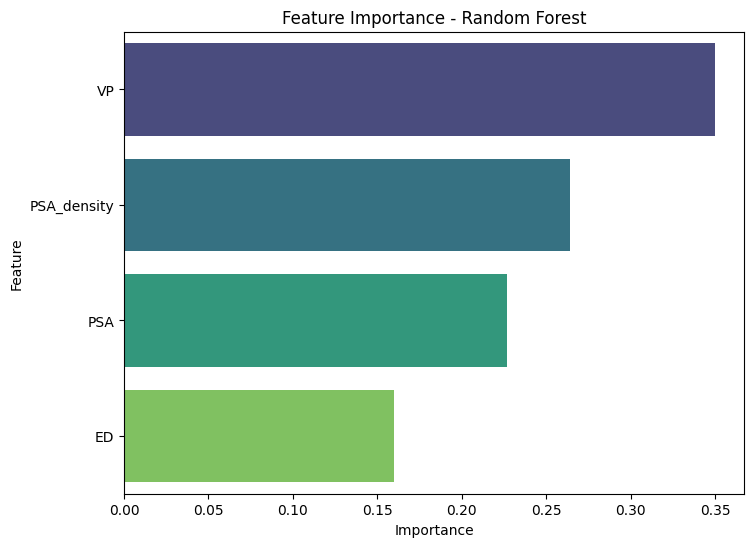

In [60]:
# Analizar importancia de características con Random Forest
rf_model = RandomForestClassifier()
rf_model.fit(X_train_scaled, y_train)
feature_importances = rf_model.feature_importances_

# Crear un dataframe con los resultados
importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Graficar importancia de características
plt.figure(figsize=(8, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [61]:
# Definir modelo de red neuronal en PyTorch
class SimpleNN(nn.Module):
    def __init__(self, in_num_features=4, n_classes=2, feature_size=48):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(in_num_features, feature_size)
        self.fc2 = nn.Linear(feature_size, feature_size)
        self.fc3 = nn.Linear(feature_size, feature_size)
        self.fc4 = nn.Linear(feature_size, feature_size)
        self.fc = nn.Linear(feature_size, feature_size)
        self.out_class = nn.Linear(feature_size, n_classes)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.relu(self.fc3(x))
        x = torch.relu(self.fc4(x))
        x = torch.relu(self.fc(x))
        x = self.out_class(x)
        return x


In [62]:
# Convertir datos a tensores para PyTorch
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

# Crear DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False) 

In [63]:
# Inicializar y entrenar la red neuronal
model_nn = SimpleNN(in_num_features=X_train.shape[1])
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_nn.parameters(), lr=0.001)

num_epochs = 20
for epoch in range(num_epochs):
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model_nn(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.4f}")

Epoch 1/20, Loss: 0.6537
Epoch 2/20, Loss: 0.6268
Epoch 3/20, Loss: 0.6402
Epoch 4/20, Loss: 0.6564
Epoch 5/20, Loss: 0.5733
Epoch 6/20, Loss: 0.4781
Epoch 7/20, Loss: 0.4892
Epoch 8/20, Loss: 0.5774
Epoch 9/20, Loss: 0.4534
Epoch 10/20, Loss: 0.5651
Epoch 11/20, Loss: 0.4035
Epoch 12/20, Loss: 0.5164
Epoch 13/20, Loss: 0.6327
Epoch 14/20, Loss: 0.4433
Epoch 15/20, Loss: 0.6376
Epoch 16/20, Loss: 0.6541
Epoch 17/20, Loss: 0.5756
Epoch 18/20, Loss: 0.5440
Epoch 19/20, Loss: 0.4079
Epoch 20/20, Loss: 0.6052


Neural Network Test Accuracy: 0.7069


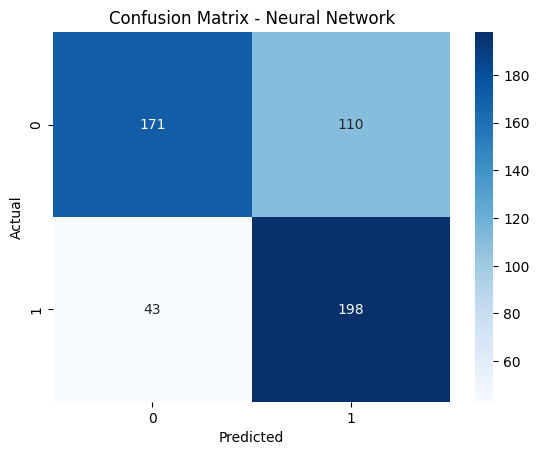

Classification Report - Neural Network:
               precision    recall  f1-score   support

           0       0.80      0.61      0.69       281
           1       0.64      0.82      0.72       241

    accuracy                           0.71       522
   macro avg       0.72      0.72      0.71       522
weighted avg       0.73      0.71      0.70       522



In [64]:
# Evaluación en test set
model_nn.eval()
correct = 0
total = 0
all_preds = []
all_labels = []
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        outputs = model_nn(batch_x)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.numpy())
        all_labels.extend(batch_y.numpy())
        total += batch_y.size(0)
        correct += (predicted == batch_y).sum().item()

accuracy_nn = correct / total
print(f"Neural Network Test Accuracy: {accuracy_nn:.4f}")

# Matriz de confusión para la red neuronal
cm_nn = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Neural Network')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("Classification Report - Neural Network:\n", classification_report(all_labels, all_preds))